# 1. Checking Python version

In [1]:
!python -V

Python 3.12.11


## 2. Verify GPU & RAM Availability

In [2]:
import torch

if torch.cuda.is_available():
    print("GPU is available!")
    !nvidia-smi
    gpu_name = torch.cuda.get_device_name()
    print(f"GPU: '{gpu_name}'")
else:
    print("GPU is NOT available.")

GPU is available!
Wed Aug 20 17:01:33 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------

In [3]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1024**3
print('Your runtime has {:.1f}GB of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('NOT using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 12.7GB of available RAM

NOT using a high-RAM runtime


# 3. Upload Image Dataset and Prepare Training Data

## 3.1 Upload images

**Option 1 - Copy from Google Drive**



In [4]:
# path of data.zip in Google Drive
zipped_data_path = '/content/drive/MyDrive/git_personal/yolo-custom-object-detection-training/data.zip'

In [5]:
from google.colab import drive
drive.mount('/content/drive')

!cp {zipped_data_path} /content

Mounted at /content/drive


## 3.2 Split images into train and validation folders

In [6]:
# Unzip images to a custom data folder
!unzip -q /content/data.zip -d /content/custom_data

In [7]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/dennislwy/yolo-custom-object-detection-training/refs/heads/develop/scripts/train_val_split.py

--2025-08-20 17:01:57--  https://raw.githubusercontent.com/dennislwy/yolo-custom-object-detection-training/refs/heads/develop/scripts/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3325 (3.2K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.25K  --.-KB/s    in 0s      

2025-08-20 17:01:58 (64.4 MB/s) - ‘/content/train_val_split.py’ saved [3325/3325]



In [8]:
# TO DO: Improve robustness of train_val_split.py script so it can handle nested data folders, etc
!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 44
Number of annotation files: 44
Images moving to train: 39
Images moving to validation: 5


# 4. Install Requirements (Ultralytics)

In [9]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.8 MB/s eta 0:00:00


## Configure Training

In [10]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 1
names:
- dog


In [11]:
# clean up labels cache (if any)
label_cache_paths = ['/content/data/train/labels.cache', '/content/data/validation/labels.cache']

for label_cache_path in label_cache_paths:
  if os.path.isfile(label_cache_path):
    os.remove(label_cache_path)

# Train Model

In [12]:
import time
from datetime import datetime
import pytz

def get_datetime(timezone='Etc/GMT-8'):
    tz = pytz.timezone(timezone)
    return datetime.now(tz)

def elapsed_time(elapsed_sec):
  hours = int(elapsed_sec // 3600)
  minutes = int((elapsed_sec % 3600) // 60)
  seconds = int(elapsed_sec % 60)

  # Display the execution time
  print(f"Execution time: {hours}hr {minutes}min {seconds}sec")

In [13]:
gpu_name = torch.cuda.get_device_name()
print(f"Using GPU '{gpu_name}'")

# batch: 16, 20, 32, 40, 64, 80, 96, 128
# worker: 8

if 'A100' in gpu_name:
  batch = 128
  workers = 24
else:
  batch = 128
  workers = 24

model = 'yolo11s.pt'
epochs = 500 # default 100
workers = 24 # default 8
batch = 128 # default 16
device = -1
imgsz = 640
save_period = -1 # default -1
patience = 200 # default 100, 0 to disable
cache = True # default False, cache dataset images in memory
exist_ok = True # default False, allows overwriting of an existing project/name directory

print(f"batch: {batch}, workers: {workers}, epochs: {epochs}")

Using GPU 'Tesla T4'
batch: 128, workers: 24, epochs: 1000


In [14]:
# measure execution time
start_time = time.time()
print(f"Start training at {get_datetime()}")

Start training at 2025-08-21 01:02:09.162838+08:00


In [15]:
!yolo detect train data={path_to_data_yaml} model={model} device={device} epochs={epochs} imgsz={imgsz} cache={cache} workers={workers} batch={batch} patience={patience} save_period={save_period} exist_ok={exist_ok}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Searching for 1 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0]
Ultralytics 8.3.182 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1000, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None

In [16]:
elapsed_time(time.time() - start_time)

Execution time: 0hr 17min 51sec


# Test Model

In [17]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=data/validation/images save=True conf=0.5

Ultralytics 8.3.182 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/5 /content/data/validation/images/33493eaa-1755424513764-cone.jpg: 640x640 2 dogs, 15.7ms
image 2/5 /content/data/validation/images/5a47956a-1755424532039-cone.jpg: 640x640 6 dogs, 15.6ms
image 3/5 /content/data/validation/images/64473c55-bkgd-1705888257612.jpg: 640x640 2 dogs, 15.6ms
image 4/5 /content/data/validation/images/72e51263-1755424431153-cone.jpg: 640x640 1 dog, 15.6ms
image 5/5 /content/data/validation/images/aae54dcb-1755425304012-cone.jpg: 640x640 1 dog, 15.6ms
Speed: 2.6ms preprocess, 15.6ms inference, 30.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


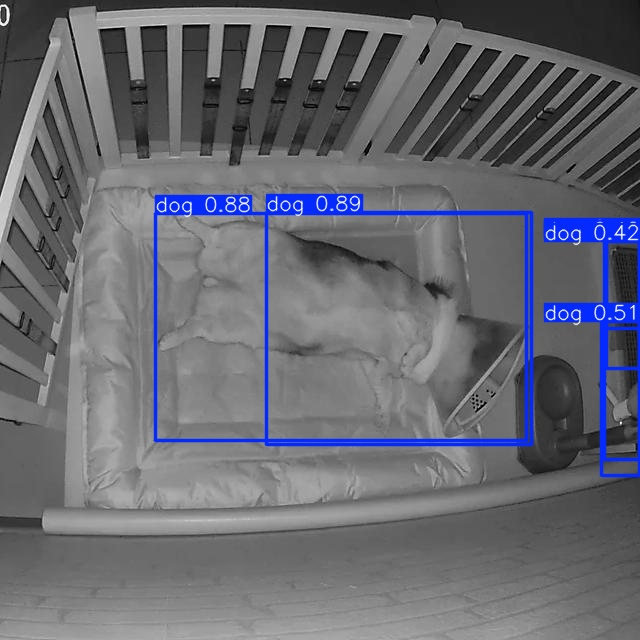

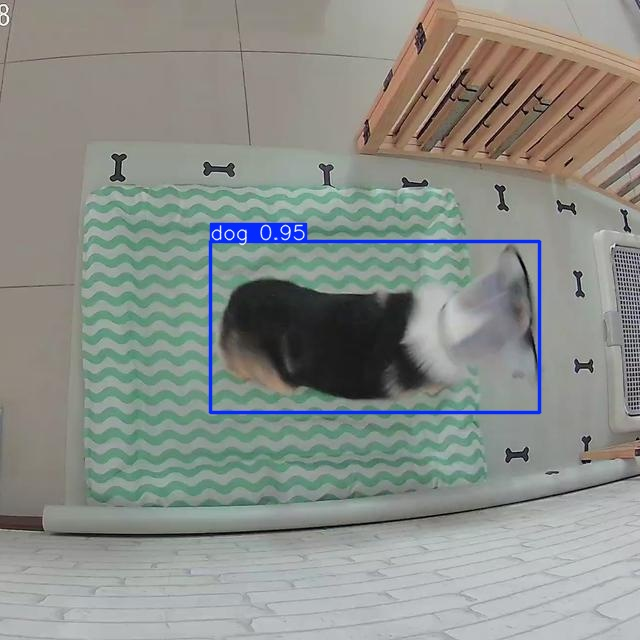

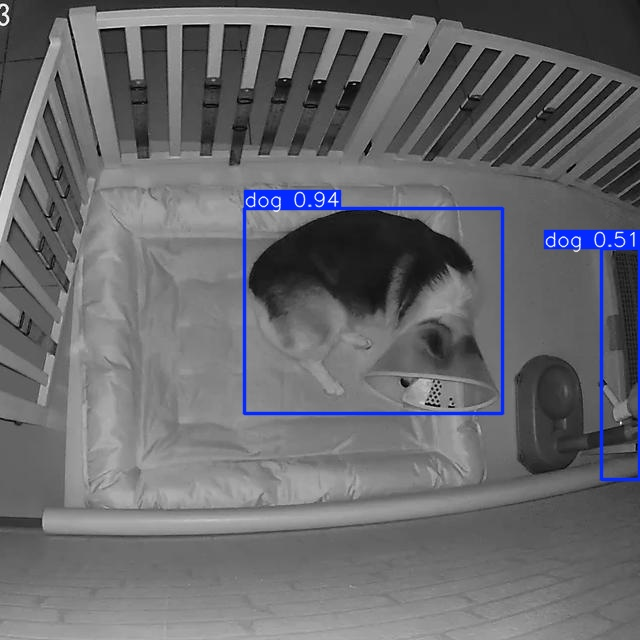

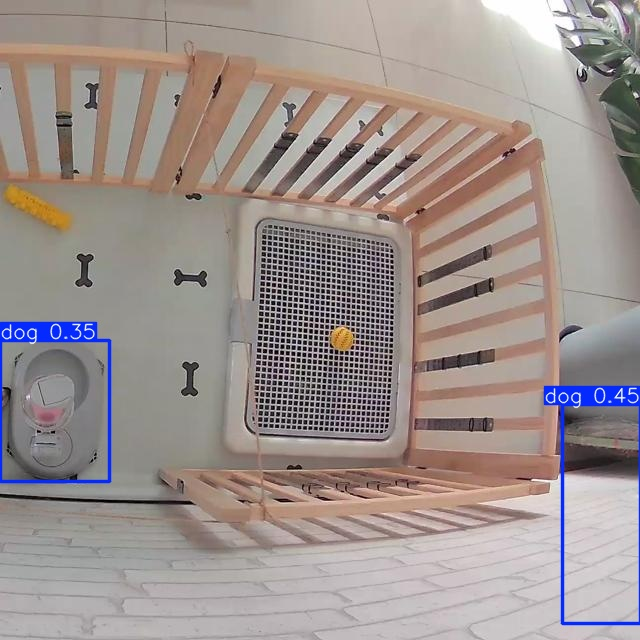

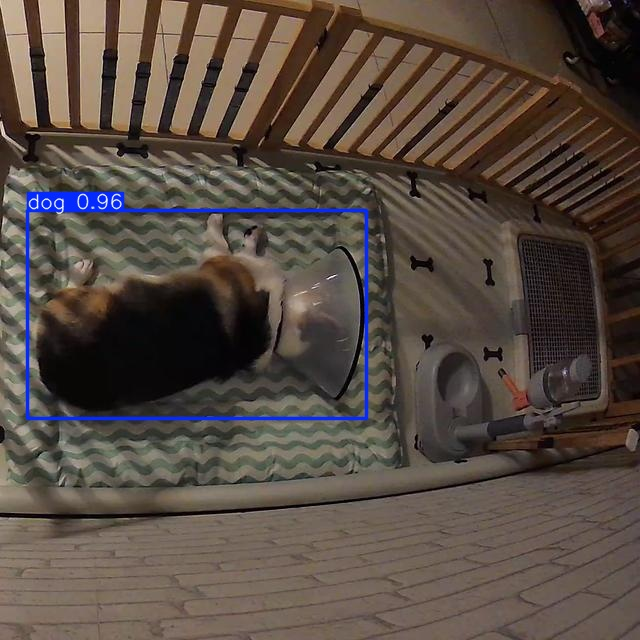

In [18]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

In [19]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=/content/drive/MyDrive/git_personal/yolo-custom-object-detection-training/dataset/val save=True conf=0.5

Ultralytics 8.3.182 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/3 /content/drive/MyDrive/git_personal/yolo-custom-object-detection-training/dataset/val/1755535310508_1.jpg: 384x640 3 dogs, 51.0ms
image 2/3 /content/drive/MyDrive/git_personal/yolo-custom-object-detection-training/dataset/val/1755535333514_1.jpg: 384x640 1 dog, 10.9ms
image 3/3 /content/drive/MyDrive/git_personal/yolo-custom-object-detection-training/dataset/val/1755535348095_1.jpg: 384x640 3 dogs, 10.9ms
Speed: 2.3ms preprocess, 24.2ms inference, 44.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [20]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict2/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

Output hidden; open in https://colab.research.google.com to view.

# Download YOLO Model

In [21]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train /content/my_model

In [22]:
# Export Model to NCNN Format
from ultralytics import YOLO

# Load your trained YOLOv11 model
model = YOLO("/content/my_model/my_model.pt")

# Export the model to NCNN format
model.export(format="ncnn")

Ultralytics 8.3.182 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from '/content/my_model/my_model.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (18.4 MB)

TorchScript: starting export with torch 2.8.0+cu126...
TorchScript: export success ✅ 4.1s, saved as '/content/my_model/my_model.torchscript' (36.5 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


NCNN: starting export with NCNN 1.0.20250503...
WARNING ⚠️ NCNN: PNNX not found. Attempting to download binary file from https://github.com/pnnx/pnnx/.
Note PNNX Binary file must be placed in c

Unzipping pnnx-20250819-linux.zip to /content/pnnx-20250819-linux...: 100%|██████████| 3/3 [00:00<00:00,  5.86file/s]

NCNN: running '/usr/local/lib/python3.12/dist-packages/ultralytics/pnnx /content/my_model/my_model.torchscript ncnnparam=/content/my_model/my_model_ncnn_model/model.ncnn.param ncnnbin=/content/my_model/my_model_ncnn_model/model.ncnn.bin ncnnpy=/content/my_model/my_model_ncnn_model/model_ncnn.py pnnxparam=/content/my_model/my_model_ncnn_model/model.pnnx.param pnnxbin=/content/my_model/my_model_ncnn_model/model.pnnx.bin pnnxpy=/content/my_model/my_model_ncnn_model/model_pnnx.py pnnxonnx=/content/my_model/my_model_ncnn_model/model.pnnx.onnx fp16=0 device=cpu inputshape="[1, 3, 640, 640]"'


NCNN: export success ✅ 5.6s, saved as '/content/my_model/my_model_ncnn_model' (36.1 MB)

Export complete (11.4s)
Results saved to /content/my_model
Predict:         yolo predict task=detect model=/content/my_model/my_model_ncnn_model imgsz=640  
Validate:        yolo val task=detect model=/content/my_model/my_model_ncnn_model imgsz=640 data=/content/data.yaml  
Visualize:       https://netron.app


'/content/my_model/my_model_ncnn_model'

In [23]:
# Zip model
from datetime import datetime
model_name = f"my_model-{get_datetime().strftime('%Y%m%d-%H%M')}"

In [24]:


%cd my_model
!zip /content/{model_name}.zip my_model.pt
!zip -r /content/{model_name}.zip my_model_ncnn_model
!zip -r /content/{model_name}.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 9%)
  adding: my_model_ncnn_model/ (stored 0%)
  adding: my_model_ncnn_model/model.ncnn.param (deflated 85%)
  adding: my_model_ncnn_model/metadata.yaml (deflated 32%)
  adding: my_model_ncnn_model/model.ncnn.bin (deflated 14%)
  adding: my_model_ncnn_model/model_ncnn.py (deflated 51%)
  adding: train/ (stored 0%)
  adding: train/train_batch1.jpg (deflated 2%)
  adding: train/args.yaml (deflated 52%)
  adding: train/confusion_matrix.png (deflated 41%)
  adding: train/confusion_matrix_normalized.png (deflated 39%)
  adding: train/BoxR_curve.png (deflated 20%)
  adding: train/labels.jpg (deflated 51%)
  adding: train/val_batch0_pred.jpg (deflated 15%)
  adding: train/val_batch0_labels.jpg (deflated 15%)
  adding: train/results.csv (deflated 64%)
  adding: train/BoxF1_curve.png (deflated 14%)
  adding: train/BoxPR_curve.png (deflated 30%)
  adding: train/labels_correlogram.jpg (deflated 54%)
  adding: train/results.png (deflated 4%)
  addi

In [25]:
# # This takes forever for some reason, you can also just download the model from the sidebar
# from google.colab import files

# files.download('/content/{model_name}.zip')

In [26]:
# copy my_model.zip to path same as zipped_data_path
save_model_path = zipped_data_path.rsplit('/', 1)[0]
!cp /content/{model_name}.zip {save_model_path}

# Terminate Runtime

In [27]:
from google.colab import runtime

print("Terminating runtime")
runtime.unassign()

Terminating runtime
